#  Aprendizaje por refuerzo CartPole-v1


¿Qué es Reinforcement Learning?
El Reinforcement Learning (RL) o Aprendizaje por Refuerzo es una rama de la inteligencia artificial donde un agente aprende a tomar decisiones interactuando con un entorno.

In [ ]:
!pip install stable-baselines3[extra] -q
!pip install gymnasium -q

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 952.1/952.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 10.4 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==========================================================
# CELDA 3 - CREAR ENTORNO, posición, velocidad, ángulo del palo, velocidad angular
# ==========================================================

env = gym.make("CartPole-v1")

env = Monitor(
    env,
    filename="./ppo_logs/monitor.csv"
)

print("Espacio de estados:")
print(env.observation_space)

print("\nEspacio de acciones:")
print(env.action_space)



Espacio de estados:
Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Espacio de acciones:
Discrete(2)


In [ ]:
# ==========================================================
# CELDA 4 - CONFIGURACIÓN PPO
# ==========================================================

model = PPO(

    policy="MlpPolicy",
    env=env,

    learning_rate=0.0003,
    gamma=0.99,

    n_steps=1024,
    batch_size=64,

    gae_lambda=0.95,
    clip_range=0.2,

    ent_coef=0.01,

    verbose=1
)

print(model)

Using cuda device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==========================================================
# CELDA 5 - ENTRENAMIENTO
# ==========================================================

timesteps = 10000

model.learn(
    total_timesteps=timesteps
)

print(
    "\nEntrenamiento finalizado"
)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 25.1     |
|    ep_rew_mean     | 25.1     |
| time/              |          |
|    fps             | 410      |
|    iterations      | 1        |
|    time_elapsed    | 2        |
|    total_timesteps | 1024     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 28.3        |
|    ep_rew_mean          | 28.3        |
| time/                   |             |
|    fps                  | 215         |
|    iterations           | 2           |
|    time_elapsed         | 9           |
|    total_timesteps      | 2048        |
| train/                  |             |
|    approx_kl            | 0.007332567 |
|    clip_fraction        | 0.074       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.687      |
|    explained_variance   | -0.0196     |
|    learning_rate        | 0.

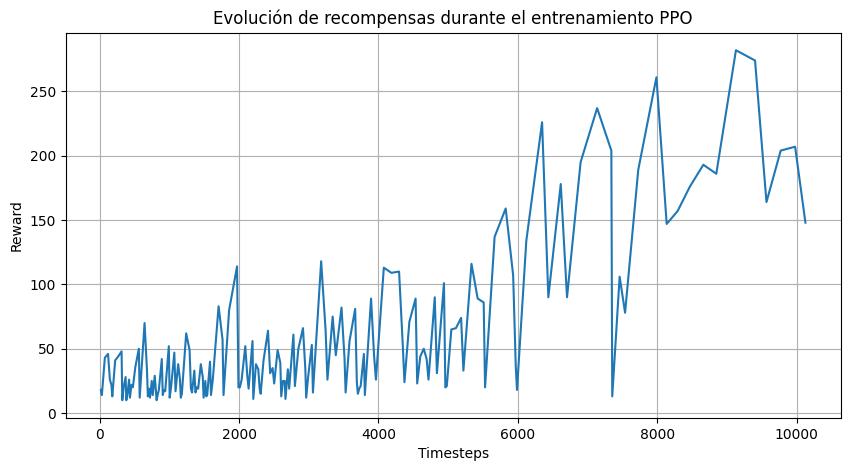

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# ==========================================================
# CELDA 6 - VISUALIZACIÓN DEL APRENDIZAJE
# ==========================================================

from stable_baselines3.common.results_plotter import load_results, ts2xy

x, y = ts2xy(
    load_results("./ppo_logs"),
    "timesteps"
)

plt.figure(figsize=(10,5))

plt.plot(x, y)

plt.xlabel("Timesteps")
plt.ylabel("Reward")

plt.title("Evolución de recompensas durante el entrenamiento PPO")

plt.grid()

plt.show()

In [ ]:
# ==========================================================
# CELDA 6 - EVALUACIÓN
# ==========================================================

mean_reward, std_reward = evaluate_policy(

    model,
    env,

    n_eval_episodes=20
)

print(
    "\nReward promedio:",
    mean_reward
)

print(
    "Desviación estándar:",
    std_reward
)



Reward promedio: 409.95
Desviación estándar: 91.67468298281702


In [ ]:

# ==========================================================
# CELDA 7 - PRUEBA DEL AGENTE
# SIN RENDER PARA EVITAR ERROR EN COLAB
# ==========================================================

test_env = gym.make(
    "CartPole-v1"
)

obs, info = test_env.reset()

total_reward = 0

acciones = []

for step in range(500):

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    acciones.append(action)

    obs, reward, terminated, truncated, info = test_env.step(
        action
    )

    total_reward += reward

    if terminated or truncated:
        break

test_env.close()

print(
    "\nPasos ejecutados:",
    len(acciones)
)

print(
    "Reward obtenida:",
    total_reward
)



Pasos ejecutados: 306
Reward obtenida: 306.0


GIF generado correctamente
Reward obtenida: 434.0


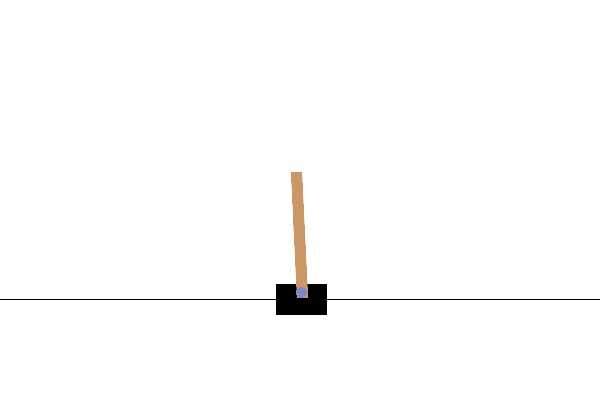

In [ ]:
# ==========================================================
# CELDA EXTRA - ANIMACIÓN PPO EN COLAB
# ==========================================================

import imageio
from IPython.display import Image, display
import os

# Crear entorno con render en imágenes
render_env = gym.make(
    "CartPole-v1",
    render_mode="rgb_array"
)

obs, info = render_env.reset()

frames = []

total_reward = 0

for step in range(500):

    # Capturar frame
    frame = render_env.render()
    frames.append(frame)

    # Predicción PPO
    action, _ = model.predict(
        obs,
        deterministic=True
    )

    # Ejecutar acción
    obs, reward, terminated, truncated, info = render_env.step(
        action
    )

    total_reward += reward

    # Terminar episodio
    if terminated or truncated:
        break

render_env.close()

# Guardar GIF
gif_path = "ppo_cartpole.gif"

imageio.mimsave(
    gif_path,
    frames,
    fps=30
)

print("GIF generado correctamente")
print("Reward obtenida:", total_reward)

# Mostrar GIF
display(Image(filename=gif_path))

In [ ]:
# ==========================================================
# CELDA 8 - EXPERIMENTOS
# MODIFICAR LR Y GAMMA
# ==========================================================

experimentos = [

    {
        "lr":0.001,
        "gamma":0.95
    },

    {
        "lr":0.0003,
        "gamma":0.99
    },

    {
        "lr":0.0001,
        "gamma":0.999
    }

]

resultados = []

for exp in experimentos:

    entorno = Monitor(
        gym.make(
            "CartPole-v1"
        )
    )

    agente = PPO(

        "MlpPolicy",

        entorno,

        learning_rate=exp["lr"],

        gamma=exp["gamma"],

        verbose=0
    )

    agente.learn(
        total_timesteps=5000
    )

    recompensa, _ = evaluate_policy(

        agente,

        entorno,

        n_eval_episodes=10
    )

    resultados.append(
        recompensa
    )

    print(
        "\nLearning Rate:",
        exp["lr"]
    )

    print(
        "Gamma:",
        exp["gamma"]
    )

    print(
        "Reward:",
        recompensa
    )

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(



Learning Rate: 0.001
Gamma: 0.95
Reward: 266.6

Learning Rate: 0.0003
Gamma: 0.99
Reward: 341.6

Learning Rate: 0.0001
Gamma: 0.999
Reward: 173.5


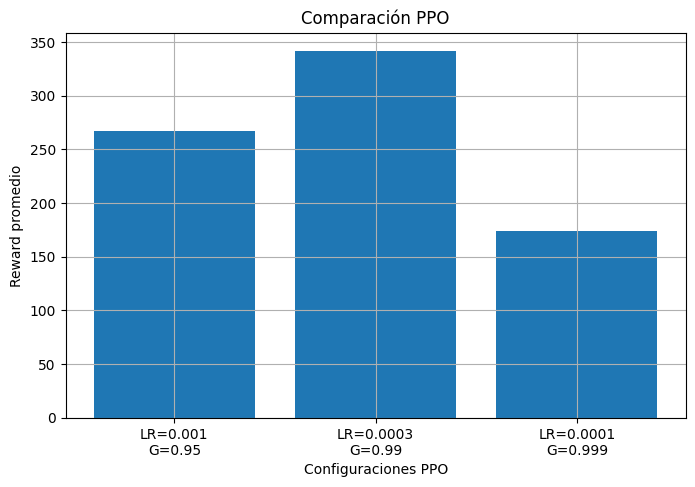

In [ ]:

# ==========================================================
# CELDA 9 - VISUALIZACIÓN
# ==========================================================

labels = [

    f"LR={e['lr']}\nG={e['gamma']}"

    for e in experimentos

]

plt.figure(
    figsize=(8,5)
)

plt.bar(
    labels,
    resultados
)

plt.xlabel(
    "Configuraciones PPO"
)

plt.ylabel(
    "Reward promedio"
)

plt.title(
    "Comparación PPO"
)

plt.grid()

plt.show()


- ¿Qué diferencia existe entre RL y aprendizaje supervisado?

La principal diferencia entre el aprendizaje por refuerzo (RL) y el aprendizaje supervisado es la forma en que aprenden los modelos. En el aprendizaje supervisado, el modelo entrena con datos etiquetados donde ya se conoce la respuesta correcta, mientras que en RL el agente aprende interactuando con un entorno y tomando decisiones para obtener mejores resultados con el tiempo. En RL no se le dice directamente cuál es la acción correcta, sino que aprende mediante prueba y error.
- ¿Qué es una recompensa?

Una recompensa es un valor numérico que el entorno entrega al agente después de realizar una acción. Esta recompensa indica si la acción fue buena o mala para alcanzar el objetivo. El agente intenta maximizar la suma de recompensas obtenidas, por lo que las utiliza como guía para aprender qué decisiones son más convenientes.
- ¿Qué representa un estado?

Un estado representa la situación actual del entorno en un momento específico. Contiene la información necesaria para que el agente pueda decidir qué acción tomar. Por ejemplo, en un videojuego, el estado podría incluir la posición del personaje, enemigos y objetos disponibles en pantalla.
- ¿Qué función cumple la política?

La política es la estrategia que utiliza el agente para decidir qué acción realizar en cada estado. En otras palabras, define el comportamiento del agente dentro del entorno. La política puede ser simple, como elegir acciones al azar, o compleja, utilizando redes neuronales para tomar decisiones más inteligentes.
- ¿Por qué el agente necesita explorar?

El agente necesita explorar porque al inicio no conoce cuáles acciones producen mejores resultados. Si solo repitiera las acciones conocidas, podría perder oportunidades de encontrar estrategias más efectivas. La exploración permite descubrir nuevas acciones y mejorar el aprendizaje, aunque algunas decisiones iniciales puedan ser incorrectas.
- ¿Qué parámetros afectan el entrenamiento?

Los parámetros que afectan el entrenamiento incluyen la tasa de aprendizaje, el número de episodios, el factor de descuento y el nivel de exploración. Estos parámetros influyen en la velocidad con la que aprende el agente, cuánto valora las recompensas futuras y el equilibrio entre explorar nuevas acciones o aprovechar las ya conocidas.